In [ ]:
!nvidia-smi

Fri Aug 12 18:18:57 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   69C    P0    29W /  70W |   2858MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

Load and prepare data.

In [ ]:
from keras.datasets.mnist import load_data

(train_X, train_y), (_, _) = load_data()
train_X.shape, train_y.shape

((60000, 28, 28), (60000,))

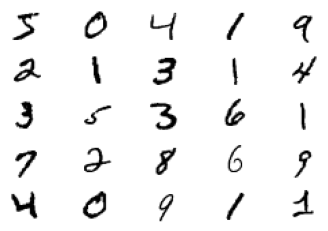

In [ ]:
import matplotlib.pyplot as plt

for i in range(25):
  plt.subplot(5, 5, 1+i)
  plt.axis(False)
  plt.imshow(train_X[i], cmap='gray_r')

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

BUFFER_SIZE = 60000
BATCH_SIZE = 256

# Normalize to [-1, 1] and reshape images for 1 channel and type float
train_X = train_X.reshape(train_X.shape[0], 28, 28, 1).astype('float32')
train_X = (train_X - 127.5) / 127.5

# batch and shuffle data
train_dataset = tf.data.Dataset.from_tensor_slices(train_X).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

Generator model.

In [ ]:
def make_generator_model():
  model = tf.keras.Sequential()
  model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU())

  model.add(layers.Reshape((7, 7, 256)))
  assert model.output_shape == (None, 7, 7, 256)

  model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
  assert model.output_shape == (None, 7, 7, 128)
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU())

  model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
  assert model.output_shape == (None, 14, 14, 64)
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU())

  model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False))
  assert model.output_shape == (None, 28, 28, 1)

  return model

def make_noise(batch, z_dim):
  return tf.random.normal([batch, z_dim])

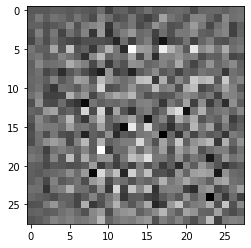

In [ ]:
generator = make_generator_model()
noise = make_noise(1, 100)

generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray_r');

Discriminator model.

In [ ]:
def make_discriminator_model():
  model = tf.keras.Sequential()
  model.add(layers.Conv2D(64, (5,5), strides=(2,2), padding='same', input_shape=[28,28,1]))
  model.add(layers.LeakyReLU())
  model.add(layers.Dropout(0.3))
  
  model.add(layers.Conv2D(128, (5,5), strides=(2,2), padding='same'))
  model.add(layers.LeakyReLU())
  model.add(layers.Dropout(0.3))

  model.add(layers.Flatten())
  model.add(layers.Dense(1))

  return model

In [ ]:
discriminator = make_discriminator_model()

pred = discriminator(generated_image)
print(pred)

tf.Tensor([[-0.00145612]], shape=(1, 1), dtype=float32)


Losses and optimizers.

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
  real_loss = cross_entropy(tf.ones_like(real_output), real_output)
  fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
  total_loss = real_loss + fake_loss
  return total_loss

def generator_loss(fake_output):
  return cross_entropy(tf.ones_like(fake_output), fake_output)

gen_opt = tf.keras.optimizers.Adam(1e-4)
disc_opt = tf.keras.optimizers.Adam(8e-5)

Checkpoint.

In [ ]:
import os

checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=gen_opt,
                                 discriminator_optimizer=disc_opt,
                                 generator=generator,
                                 discriminator=discriminator)

Loop de treinamento.

In [ ]:
from urllib.parse import ParseResult
import time

from IPython import display

EPOCHS = 50
Z_DIM = 100
num_examples_to_generate = 16

gen_losses = []
disc_losses = []

# we will use this seed overtime to visualize progress
seed = tf.random.normal([num_examples_to_generate, Z_DIM])

def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for image_batch in dataset:
      disc_loss, gen_loss = train_step(image_batch)
      gen_losses.append(gen_loss)
      disc_losses.append(disc_loss)

    # produces images to visualize progress
    display.clear_output(wait=True)
    print('Epoch: ', epoch)
    generate_and_save_images(generator, epoch + 1, seed)

    # save model every 15 epochs
    if (epoch + 1) % 15 == 0:
      checkpoint.save(file_prefix = checkpoint_prefix)
    
  # Generate final images
  display.clear_output(wait=True)
  generate_and_save_images(generator, epochs, seed)

@tf.function
def train_step(images):
  noise = make_noise(BATCH_SIZE, Z_DIM)

  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    fake_images = generator(noise, training=True)

    real_output = discriminator(images, training=True)
    fake_output = discriminator(fake_images, training=True)

    disc_loss = discriminator_loss(real_output, fake_output)
    gen_loss = generator_loss(fake_output)

  gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
  gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

  gen_opt.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
  disc_opt.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

  return disc_loss, gen_loss


def generate_and_save_images(model, epoch, seed):
  fake_images = model(seed, training=False)

  fig = plt.figure(figsize=(4,4))

  for i in range (fake_images.shape[0]):
    plt.subplot(4, 4, i+1)
    plt.imshow(fake_images[i, :, :, 0] * 127.5 + 127.5, cmap='gray_r')
    plt.axis(False)

  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

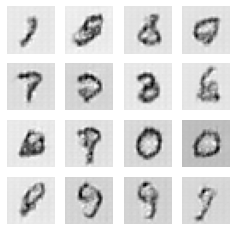

In [ ]:
train(train_dataset, EPOCHS)

Create a gif.

In [ ]:
import imageio
import glob

anim_file = 'dcgan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
  filenames = glob.glob('image*.png')
  filenames = sorted(filenames)

  for filename in filenames:
    image = imageio.imread(filename)
    writer.append_data(image)

  image = imageio.imread(filename)
  writer.append_data(image)

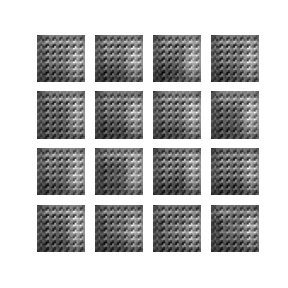

In [ ]:
from IPython.display import Image
Image(open('dcgan.gif','rb').read())

Generating random number.

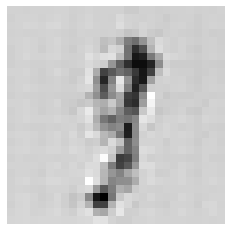

In [ ]:
noise = make_noise(1, Z_DIM)

fake_image = generator(noise, training=False)

plt.figure(figsize=(4,4))
plt.imshow(fake_image[0, :, :, 0], cmap='gray_r')
plt.axis(False);

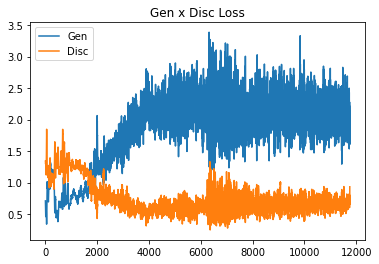

In [ ]:
plt.plot(tf.squeeze(gen_losses).numpy(), label='Gen')
plt.plot(tf.squeeze(disc_losses).numpy(), label='Disc')
plt.legend()
plt.title('Gen x Disc Loss')
plt.show();

To study:

https://arxiv.org/pdf/1701.00160.pdf